# Koopman Operator Training with Autoencoder

This notebook implements a training pipeline for a Koopman operator model combined with an autoencoder. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [1]:
import os
# Move up one directory to make sure the script can find the modules and save files in the correct place
os.chdir('..')
# Verify the current working directory
print(os.getcwd())

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from KoopmanTrainer_AFT_DR import Trainer
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.efficient_kan import *
from models.koopman_operator import Knet
from models.AFT import AttentionFreeTransformer

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)


/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder


## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [2]:
# the version of pandas
def get_pandas_version():
    import numpy as np
    import pandas as pd
    return pd.__version__
print(f"Pandas version: {get_pandas_version()}")
import numpy as np
print(f"NumPy version: {np.__version__}")

Pandas version: 2.2.2
NumPy version: 2.0.1


In [3]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [4]:
# editing the args 
# in this experiement we increased the timesteps to 201 and the time to 40 which is double the original experiment to make sure we would capture the limit cycle 
args.dataset = 'Rossler'
args.folder = 'Rossler_AFT_Dynamic_Reencoding'
args.time_steps = 1000
args.prediction_length = 30
args.max_time = 50
args.num_samples = 2000
args.bottleneck = 128
args.decoder_loss_weight = .1
args.lr = 1e-3
args.epochs = 50
args.loss_function = 'mse'
args.unitary_loss_weight = 10
args.context_length = 10
args.load_from_checkpoint = True
args.encoder_hidden_layers = [128, 128, 128, 128]
#args.batch_size = 265


## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [5]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [6]:
# Convert args to a dictionary for the data handler

config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": args.normalize,
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta
}

# Initialize data handler
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get data dimensions for model initialization
input_size = preprocessed_data['Xtrain'].shape[-1]

100%|██████████| 2000/2000 [00:00<00:00, 24088.24it/s]

the shape of the data is torch.Size([2000, 1000, 3])
Processing dataset: Rossler
train_idx: 1600, val_idx: 1800
Processed data shapes - Train: torch.Size([1600, 1000, 3]), Val: torch.Size([200, 1000, 3]), Test: torch.Size([200, 1000, 3])



/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than to

## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [7]:
# Model definition
ae = AutoEncoder(
    input_size=input_size,
    encoded_size=args.bottleneck,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet = Knet(size=args.bottleneck)

AFT = AttentionFreeTransformer(d_model=args.bottleneck, max_seq_len=args.context_length, device=device)

# Combine AE and Knet as a ModuleDict
model = torch.nn.ModuleDict({'ae': ae, 'knet': knet,'aft_layer': AFT})
model = model.to(device)

## Model Summary

Display the total number of parameters and the model architecture.

In [8]:
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model.parameters())/1000.0))
print('************')

print('**** Model Architecture ****')
print(model)
print('***************************')

**** Setup ****
Total params: 0.20M
Total params: 199.01k
************
**** Model Architecture ****
ModuleDict(
  (ae): AutoEncoder(
    (encoder): Sequential(
      (0): MLP(
        (net): ModuleList(
          (0): Linear(in_features=3, out_features=128, bias=True)
          (1): LeakyReLU(negative_slope=0.01)
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): LeakyReLU(negative_slope=0.01)
          (4): Linear(in_features=128, out_features=128, bias=True)
          (5): LeakyReLU(negative_slope=0.01)
          (6): Linear(in_features=128, out_features=128, bias=True)
          (7): LeakyReLU(negative_slope=0.01)
          (8): Linear(in_features=128, out_features=128, bias=True)
        )
      )
      (1): Dropout(p=0.3, inplace=False)
    )
    (decoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=128, out_features=128, 

## Load from Checkpoint

Optionally load a pre-trained model from a checkpoint if specified.

In [9]:
if args.load_from_checkpoint:
    checkpoint_path = os.path.join(folder_path, 'model.pkl')
    if os.path.isfile(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
        print(f'Model loaded from {checkpoint_path}')
    else:
        print(f'No checkpoint found at {checkpoint_path}')

Model loaded from experiments/Rossler_AFT_Dynamic_Reencoding/model.pkl


/var/folders/5_/hq2ly88s2fxbtph44558kg8m0000gn/T/ipykernel_61991/546321609.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_pa


## Training

Train the model using the `Trainer` class with the specified data loaders.

In [10]:
trainer = Trainer(model, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)

Using the CPU


In [11]:
trainer.train_KoopmanAE()

Training Epochs:  10%|█         | 5/50 [11:15<1:41:22, 135.16s/it]

Epoch 5/50
Training - Recon Loss: 2.461360e-04, Linear Loss: 1.866914e-05, Pred Loss: 4.377075e-04, Unitary Loss: 9.295317e-07, Total Loss: 9.634880e-05
Validation - Recon Loss: 1.153451e-04, Linear Loss: 6.058881e-06, Pred Loss: 4.478258e-04,Unitary Loss: 1.019839e-06, Total Loss: 6.237597e-05


Training Epochs:  20%|██        | 10/50 [22:03<1:27:43, 131.59s/it]

Epoch 10/50
Training - Recon Loss: 1.741715e-04, Linear Loss: 1.324897e-05, Pred Loss: 3.227735e-04, Unitary Loss: 9.022825e-07, Total Loss: 7.196630e-05
Validation - Recon Loss: 2.446341e-05, Linear Loss: 3.611480e-06, Pred Loss: 1.848883e-04,Unitary Loss: 1.182278e-06, Total Loss: 2.454665e-05


Training Epochs:  30%|███       | 15/50 [32:51<1:15:09, 128.84s/it]

...

Training Epochs:  90%|█████████ | 45/50 [1:38:41<11:11, 134.38s/it]

Epoch 45/50
Training - Recon Loss: 6.414286e-05, Linear Loss: 3.836152e-06, Pred Loss: 1.028517e-04, Unitary Loss: 6.056493e-07, Total Loss: 2.659211e-05
Validation - Recon Loss: 2.580431e-05, Linear Loss: 1.033342e-06, Pred Loss: 3.639683e-05,Unitary Loss: 5.982913e-07, Total Loss: 7.253456e-06


Training Epochs: 100%|██████████| 50/50 [1:49:39<00:00, 131.60s/it]

Epoch 50/50
Training - Recon Loss: 6.025722e-05, Linear Loss: 3.477029e-06, Pred Loss: 9.441602e-05, Unitary Loss: 6.062443e-07, Total Loss: 2.500680e-05
Validation - Recon Loss: 1.959286e-05, Linear Loss: 9.506012e-07, Pred Loss: 3.108897e-05,Unitary Loss: 4.640712e-07, Total Loss: 6.018784e-06


(ModuleDict(
   (ae): AutoEncoder(
     (encoder): Sequential(
       (0): MLP(
         (net): ModuleList(
           (0): Linear(in_features=3, out_features=128, bias=True)
           (1): LeakyReLU(negative_slope=0.01)
           (2): Linear(in_features=128, out_features=128, bias=True)
           (3): LeakyReLU(negative_slope=0.01)
           (4): Linear(in_features=128, out_features=128, bias=True)
           (5): LeakyReLU(negative_slope=0.01)
           (6): Linear(in_features=128, out_features=128, bias=True)
           (7): LeakyReLU(negative_slope=0.01)
           (8): Linear(in_features=128, out_features=128, bias=True)
         )
       )
       (1): Dropout(p=0.3, inplace=False)
     )
     (decoder): MLP(
       (net): ModuleList(
         (0): Linear(in_features=128, out_features=128, bias=True)
         (1): LeakyReLU(negative_slope=0.01)
         (2): Linear(in_features=128, out_features=128, bias=True)
         (3): LeakyReLU(negative_slope=0.01)
         (4): Linear(

In [12]:
trainer.test_KoopmanAE(test_loader)

Test - Recon Loss: 1.952279e-05, Linear Loss: 9.514683e-07, Pred Loss: 3.091426e-05, Total Loss: 5.995174e-06


## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

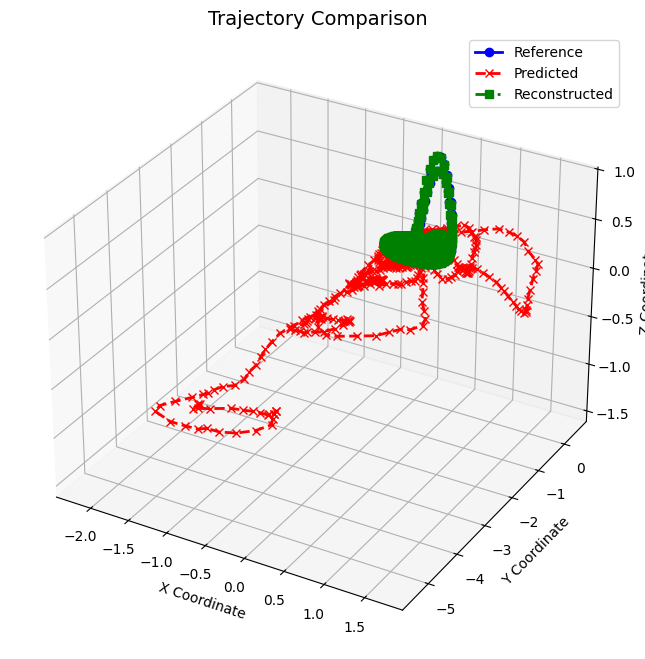

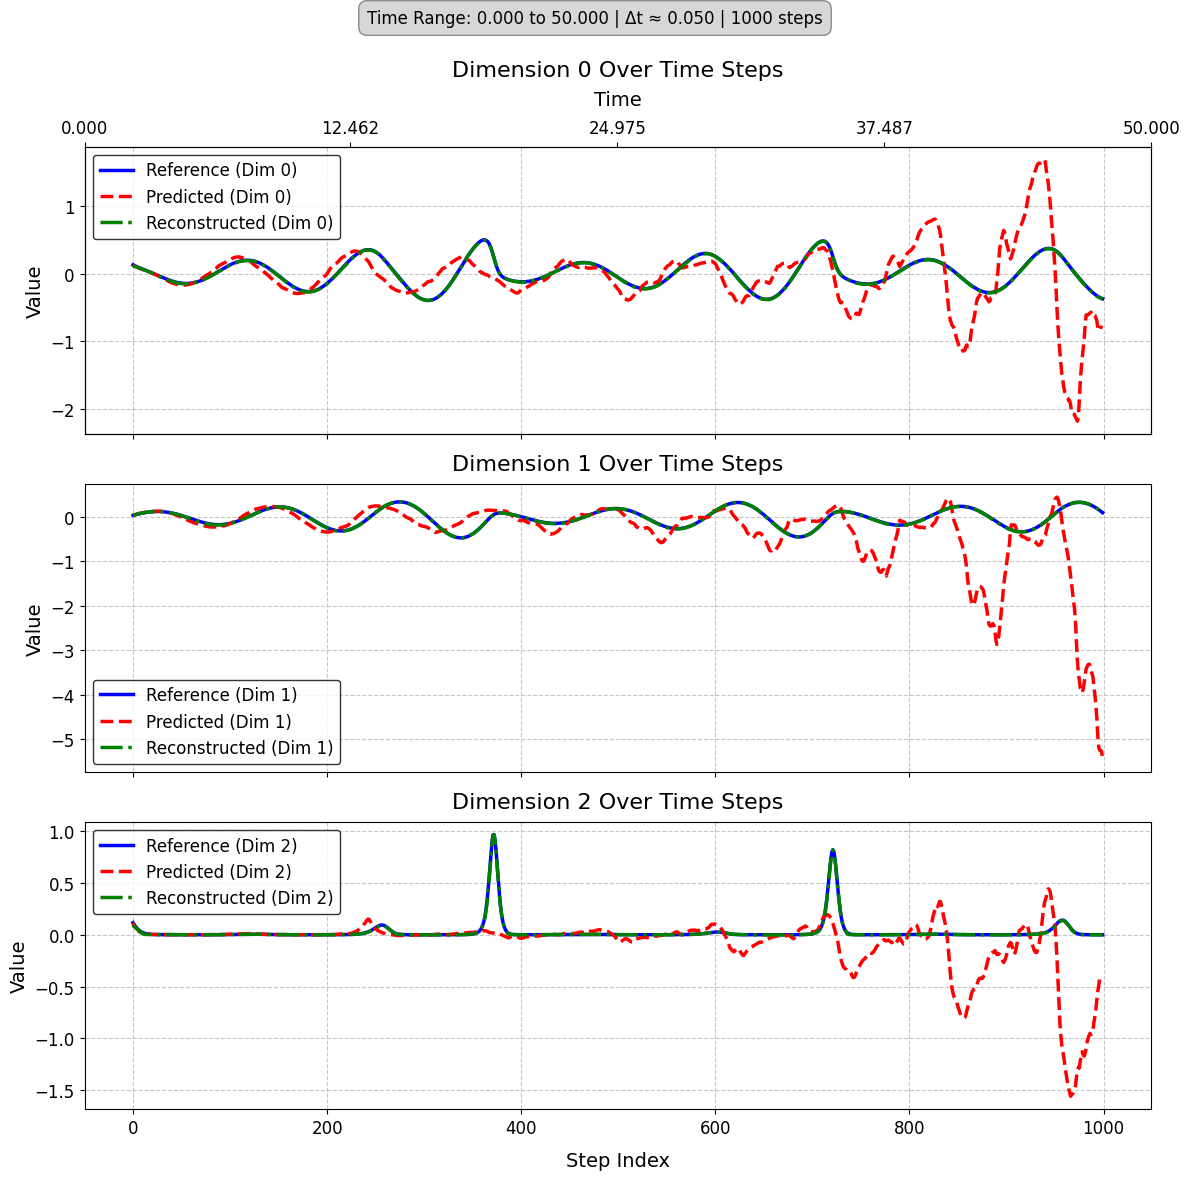

In [11]:
# for saving the results first

# Get a test sample
traj = preprocessed_data["Xtest"][0].to(device)


# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
times = np.linspace(0, args.max_time, len(traj))
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False, time = times)

### Predict without Reencoding

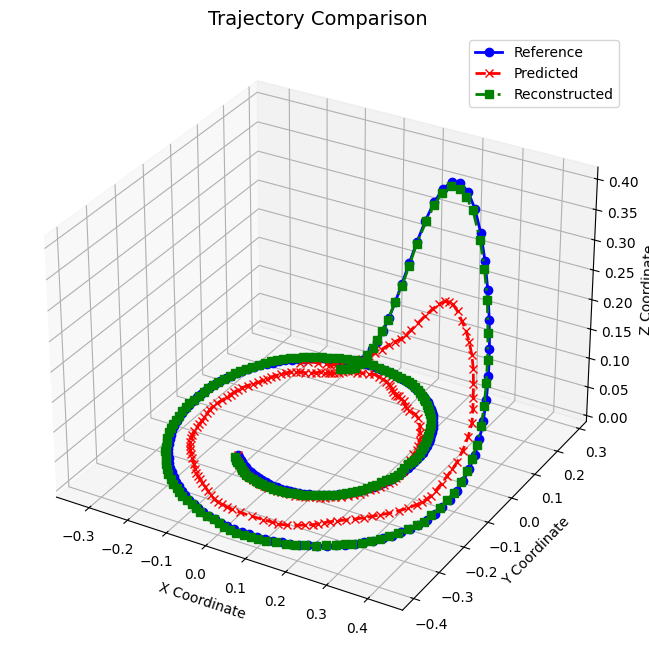

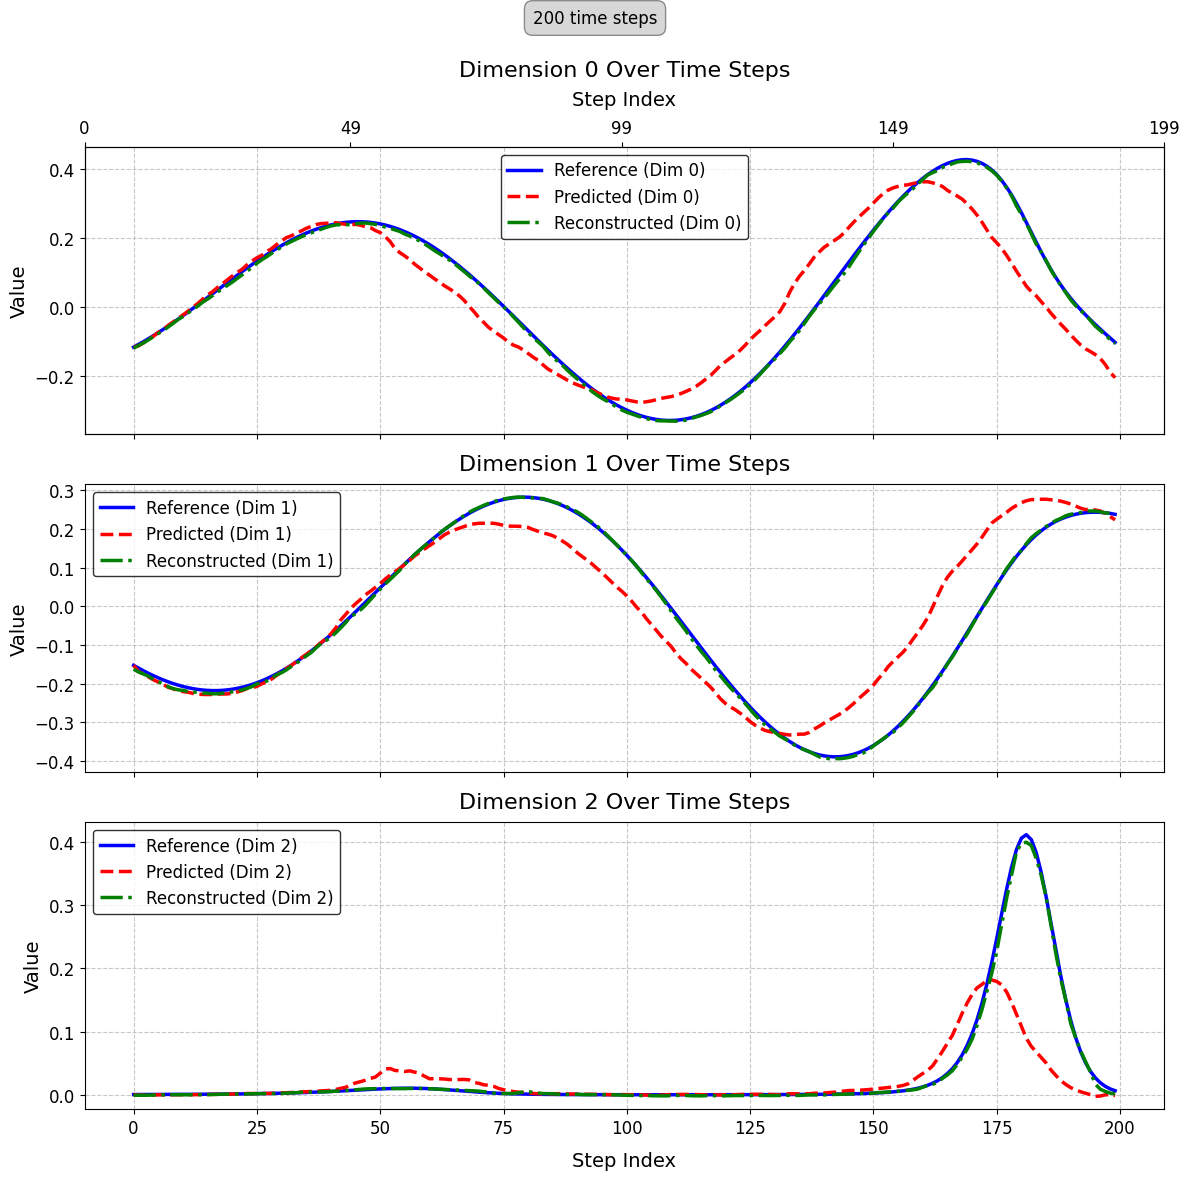

In [13]:
i = 1 ## prediction index in the trajectory
index = 1
# Get a test sample
traj = preprocessed_data["Xtest"][index][i*200:i*200+200].to(device)
#traj = preprocessed_data["Xtest"][index].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Reencoding

### Periodic Reencoding

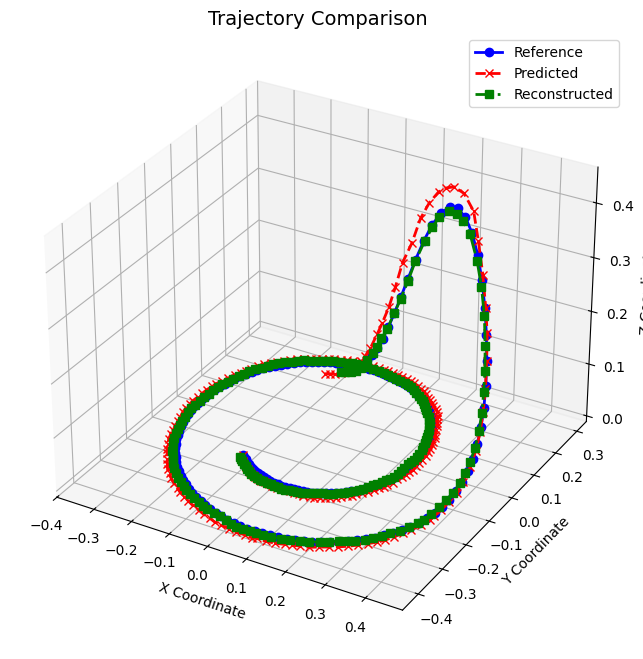

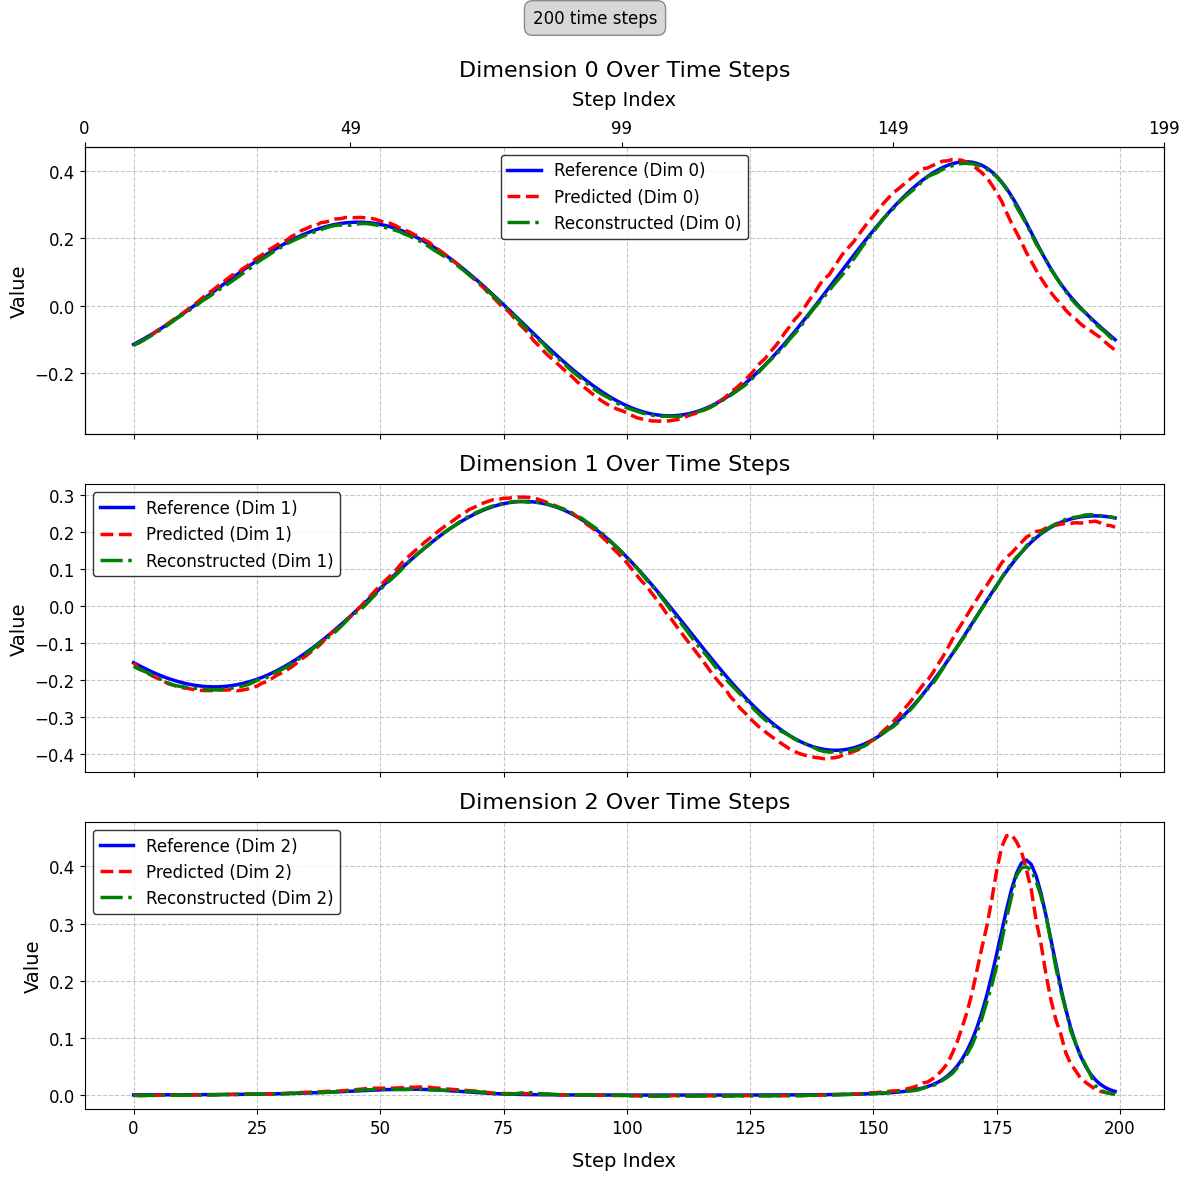

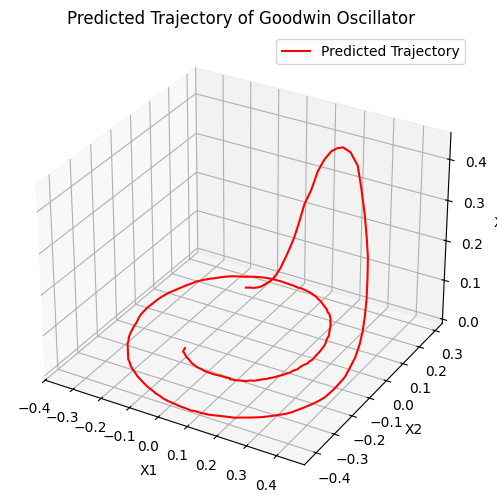

In [14]:
# for saving the results first

i = 1 
index = 1
traj = preprocessed_data["Xtest"][index][i*200:i*200+200].to(device)
#traj = preprocessed_data["Xtest"][4].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new_Periodic_Reencoding(X0=traj[0], steps=len(traj)-1,reenc=20)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)


# plot only the predicted_traj in 3d format 
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(predicted_traj[:, 0], predicted_traj[:, 1], predicted_traj[:, 2], label='Predicted Trajectory', color='red')
ax.set_title('Predicted Trajectory of Goodwin Oscillator')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.legend()
plt.show()

### Window Approach

Reencoding points: [21, 51, 75, 107, 109, 111, 113, 136, 146, 181, 190]


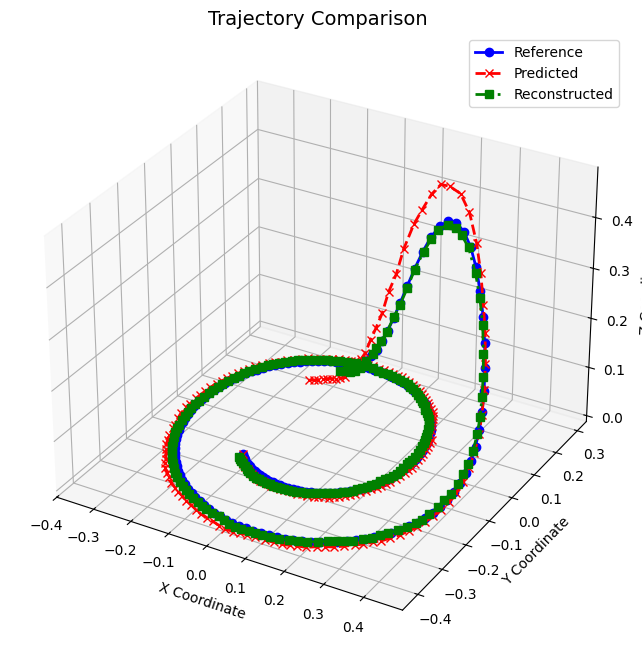

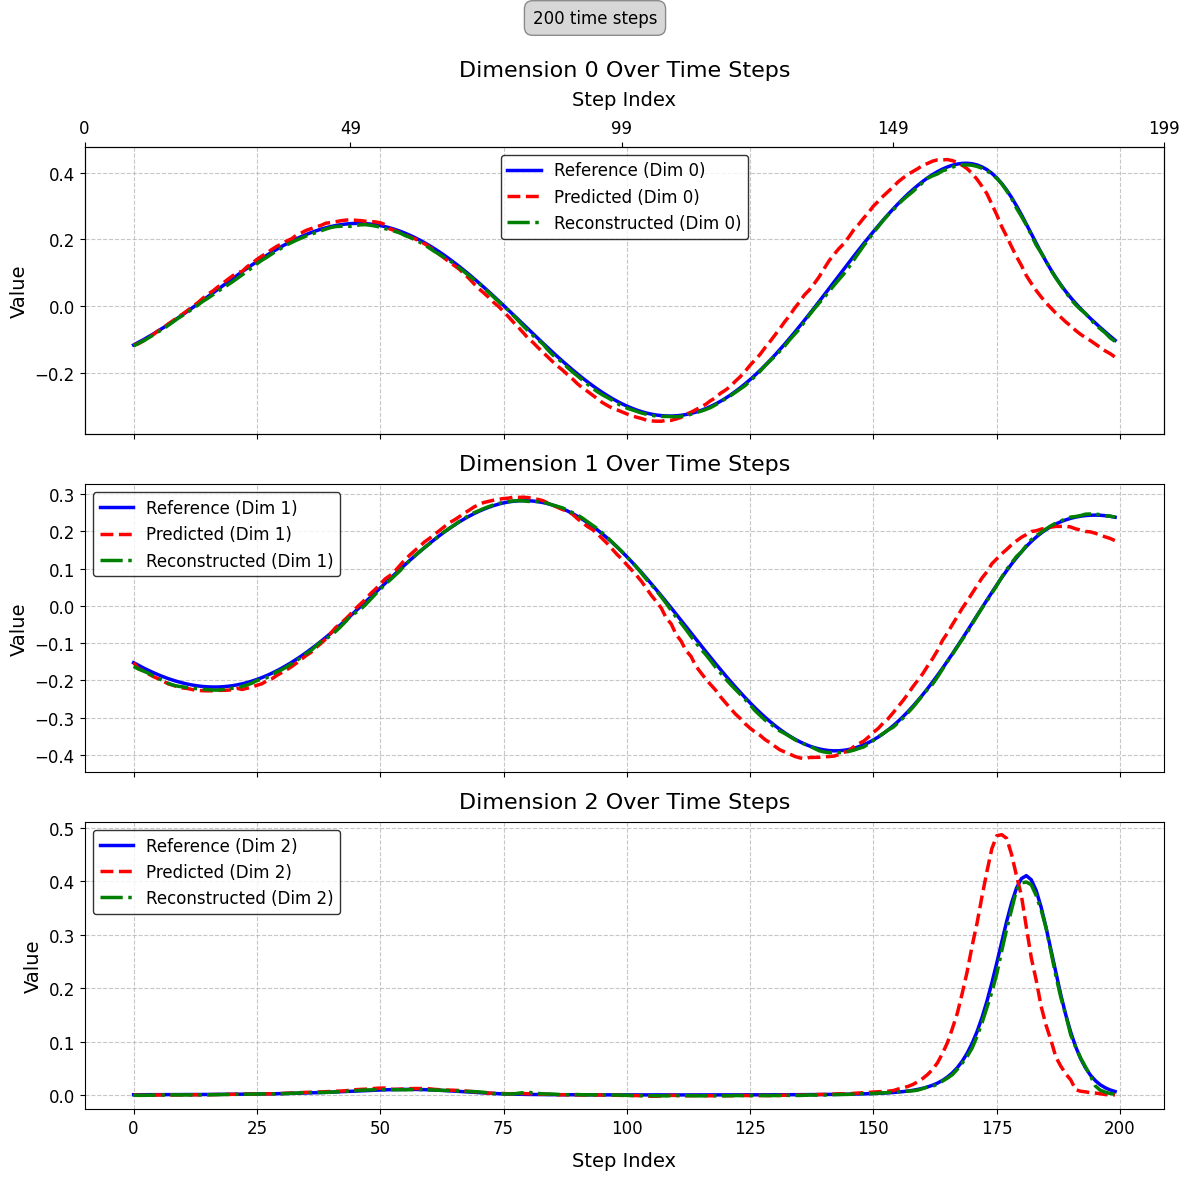

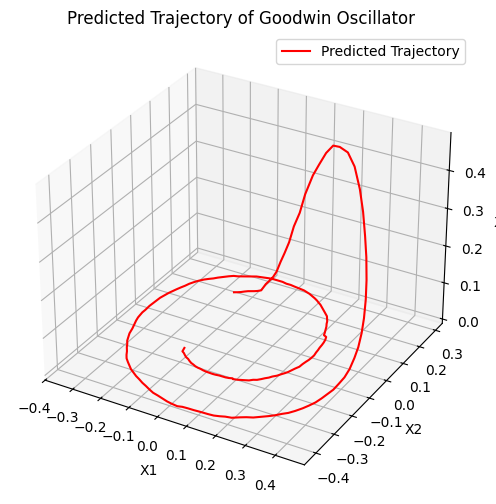

In [15]:
# for saving the results first

# Get a test sample
index = 1
i = 1
traj = preprocessed_data["Xtest"][index][i*200:i*200+200].to(device)
#traj = preprocessed_data["Xtest"][20].to(device)


# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred, reencoding_points, _ = trainer.predict_new_window_variance(X0=traj[0], steps=len(traj)-1, window_size=20, variance_threshold=2)

print(f"Reencoding points: {reencoding_points}")
# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)


# plot only the predicted_traj in 3d format 
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(predicted_traj[:, 0], predicted_traj[:, 1], predicted_traj[:, 2], label='Predicted Trajectory', color='red')
ax.set_title('Predicted Trajectory of Goodwin Oscillator')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.legend()
plt.show()

### Threshold Approach

Reencoding points: [19, 110, 140, 183]


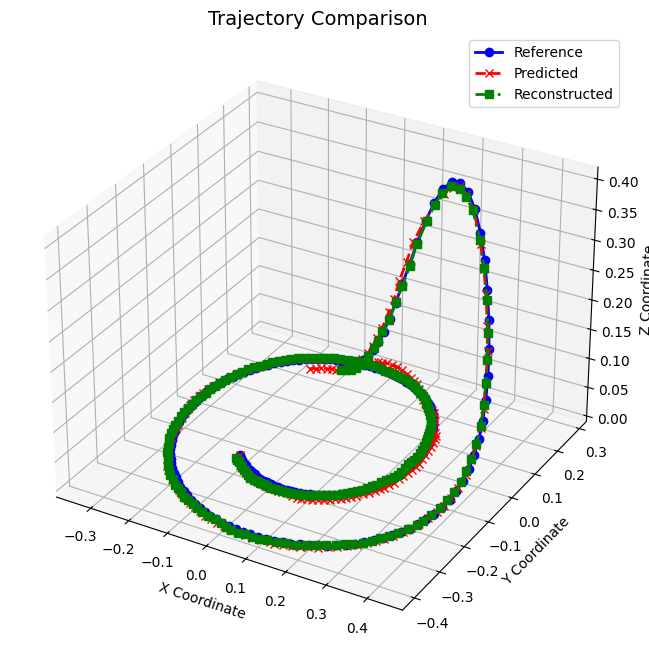

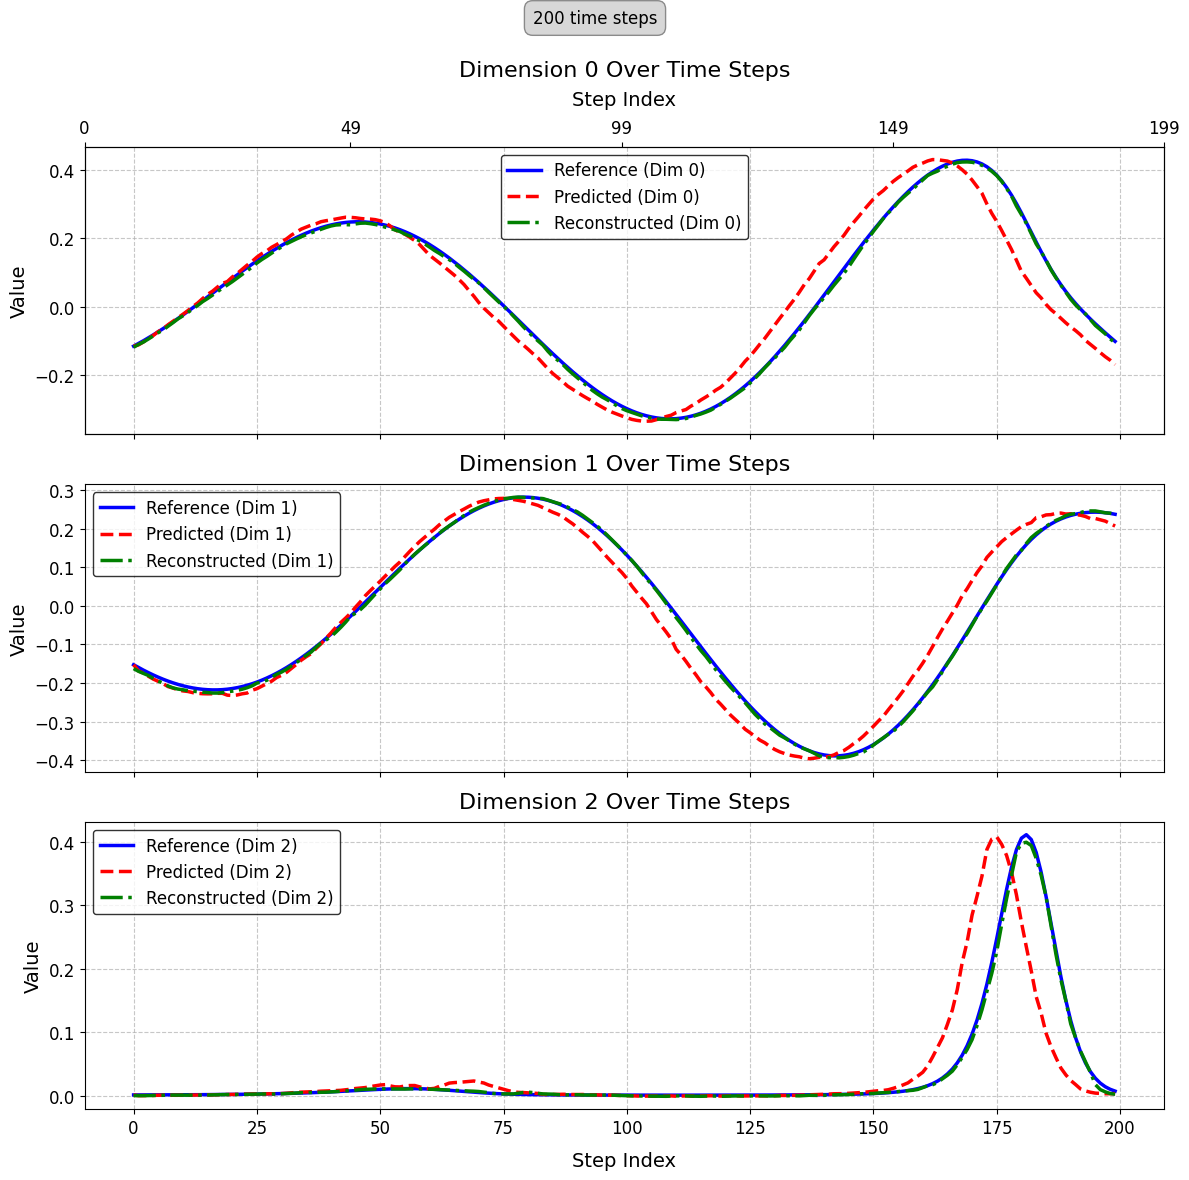

In [16]:
# for saving the results first

# Get a test sample
traj = preprocessed_data["Xtest"][index][i*200:i*200+200].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred, reencoding_points = trainer.predict_with_threshold(X0=traj[0], steps=len(traj)-1, threshold=0.3)

print(f"Reencoding points: {reencoding_points}")
# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Testing on Test Loader

In [30]:
# print length of test_loader
print(f" the length of the test_loader is {len(test_loader.dataset)}")

 the length of the test_loader is 6600


In [31]:
print(test_loader.dataset[0][0].shape)

torch.Size([31, 3])


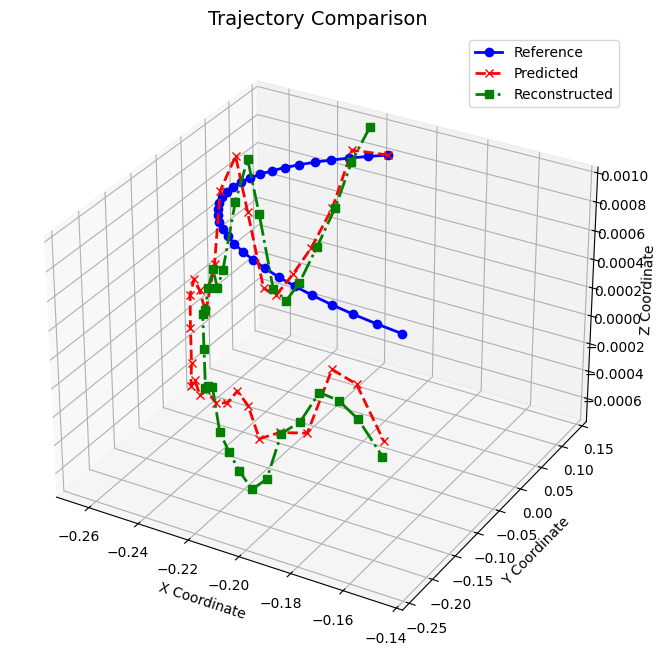

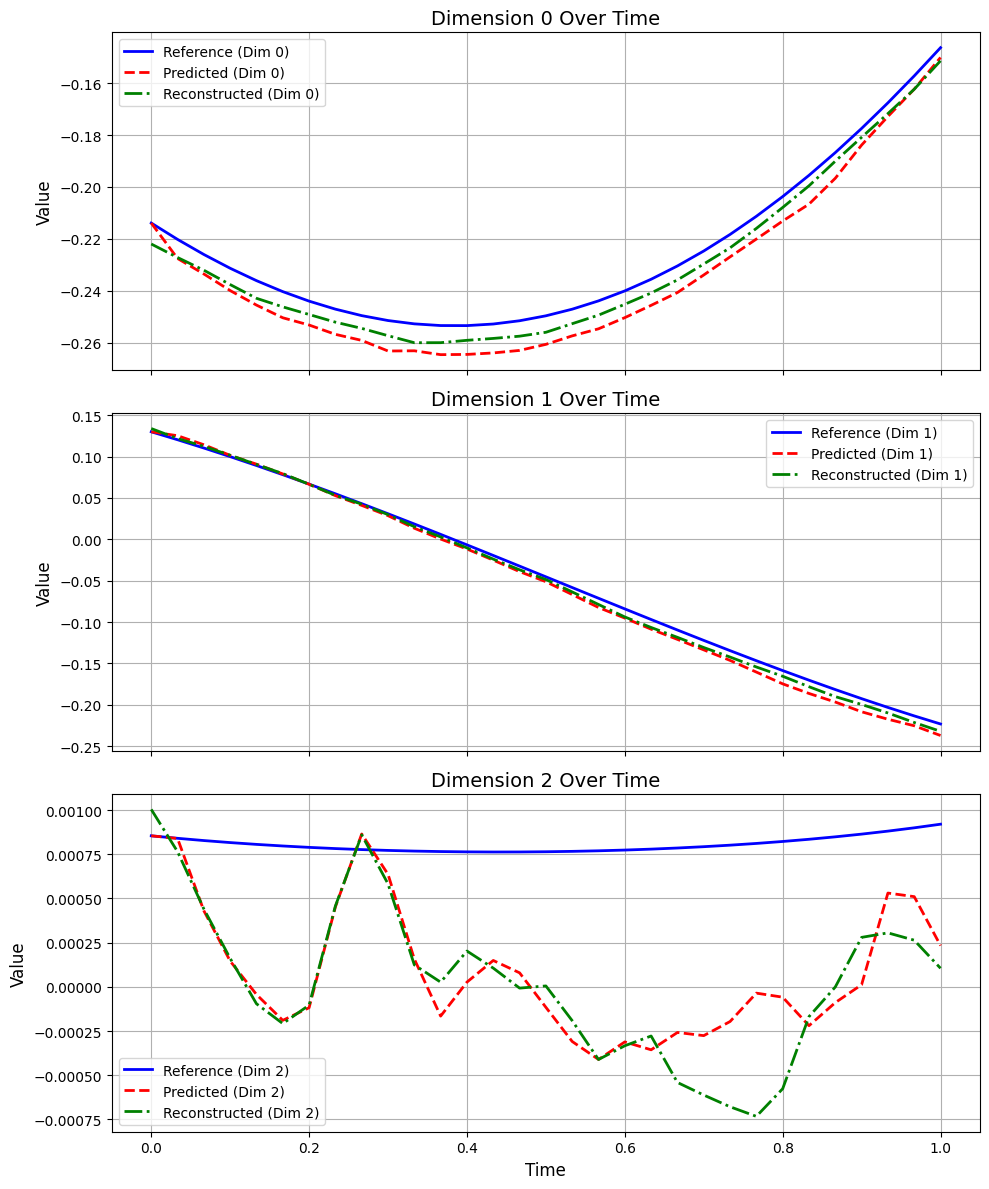

In [32]:
# Get a test sample
traj = train_loader.dataset[76][0].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

### Calculate the error rates

In [51]:
def evaluate_all_methods(preprocessed_data, model, trainer, device):
    model.eval()
    Xtest = preprocessed_data["Xtest"]

    # Define the inference methods
    def ae_reconstruction(traj):
        with torch.no_grad():
            _, reconstructed = model.ae(traj)
        return reconstructed

    def predict_new(traj):
        return trainer.predict_new(X0=traj[0], steps=len(traj) - 1)[0]

    def predict_new_periodic(traj):
        return trainer.predict_new_Periodic_Reencoding(X0=traj[0], reenc=20, steps=len(traj) - 1)[0]

    def predict_with_threshold(traj):
        return trainer.predict_with_threshold(X0=traj[0], threshold=0.5, steps=len(traj) - 1)[0]

    def predict_window_variance(traj):
        return trainer.predict_window_variance(X0=traj[0], window_size=10, variance_threshold=2, steps=len(traj) - 1)[0]

    methods = {
        #"ae_reconstruction": ae_reconstruction,
        "predict_new": predict_new,
        "predict_new_periodic": predict_new_periodic,
        "predict_with_threshold": predict_with_threshold,
        "predict_window_variance": predict_window_variance,
    }


    testing_results = {}
    for name, func in methods.items():
        print(f"Evaluating method: {name}")
        result = []
        for traj in Xtest:
            traj = traj.to(device)
            predicted_traj = func(traj)
            mse_diff = torch.mean((predicted_traj - traj) ** 2).item()
            result.append(mse_diff)
        testing_results[name] = np.mean(result)


    return testing_results


# Evaluate all methods
results = evaluate_all_methods(preprocessed_data, model, trainer, device)

print("Evaluation Results:")
for method, mse in results.items():
    print(f"{method}: MSE = {mse:.4f}")


Evaluating method: predict_new
Evaluating method: predict_new_periodic
Evaluating method: predict_with_threshold
Evaluating method: predict_window_variance
Evaluation Results:
predict_new: MSE = 25.2079
predict_new_periodic: MSE = 0.0152
predict_with_threshold: MSE = 0.0143
predict_window_variance: MSE = 0.0383


## Eigenvalues Visualization

Compute and visualize the eigenvalues of the Koopman operator on a unit circle.

Eigenvalues:
[ 0.9997755 -0.03060482j  0.9997755 +0.03060482j  0.9978739 +0.067474j
  0.9978739 -0.067474j    0.9958514 +0.0896965j   0.9958514 -0.0896965j
  0.99083745+0.13471806j  0.99083745-0.13471806j  0.9791901 +0.20297006j
  0.9791901 -0.20297006j  0.9681841 -0.2502046j   0.9681841 +0.2502046j
  0.95701635+0.29004043j  0.95701635-0.29004043j  0.94551456+0.32559308j
  0.94551456-0.32559308j  0.9267299 -0.37571302j  0.9267299 +0.37571302j
  0.90925515+0.4162403j   0.90925515-0.4162403j   0.8768066 +0.48084602j
  0.8768066 -0.48084602j  0.8432045 -0.5375643j   0.8432045 +0.5375643j
  0.8154986 -0.5787427j   0.8154986 +0.5787427j   0.7834071 -0.6215108j
  0.7834071 +0.6215108j   0.7491642 +0.66238797j  0.7491642 -0.66238797j
  0.71311426-0.7010406j   0.71311426+0.7010406j   0.68769234-0.72599524j
  0.68769234+0.72599524j  0.6398277 +0.7685076j   0.6398277 -0.7685076j
  0.58250016+0.8128407j   0.58250016-0.8128407j   0.5664615 -0.82409745j
  0.5664615 +0.82409745j  0.5217901 +0.853086

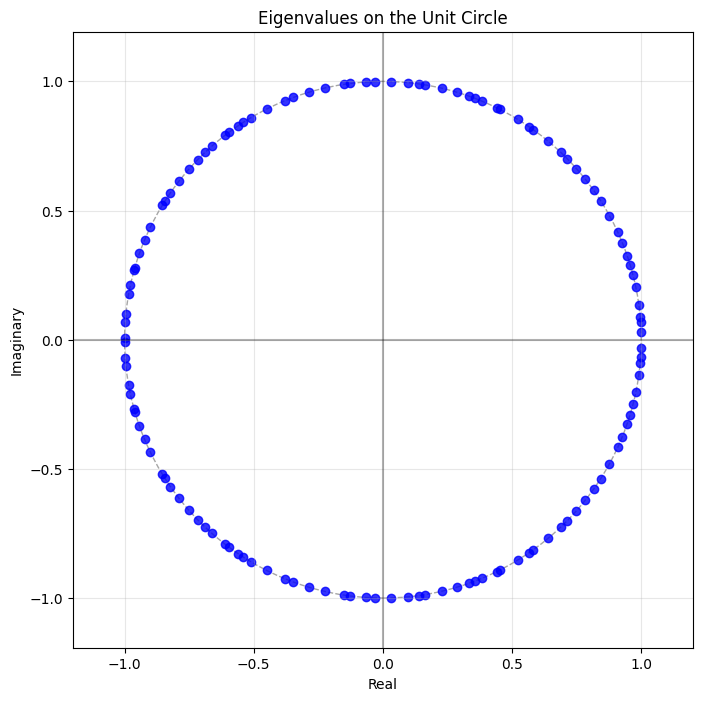

In [11]:
# Compute eigenvalues
eigenvalues, eigenvectors = torch.linalg.eig(model.knet.net.weight)
eigenvalues = eigenvalues.cpu().detach().numpy()
idx = np.argsort(eigenvalues.real)[::-1]
eigenvalues = eigenvalues[idx]

# Print eigenvalues
print('Eigenvalues:')
print(eigenvalues)

# Plot eigenvalues on unit circle
plot_eigenvalues_on_unit_circle(eigenvalues, folder_path)

print(f"Training and evaluation completed. Results saved in {folder_path}")

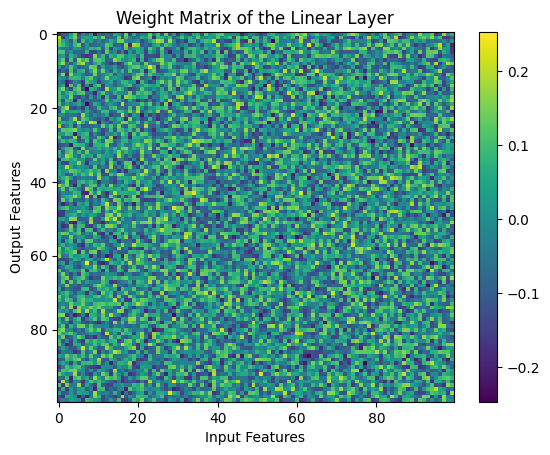

In [23]:
# print the knet weights
weights = model.knet.net.weight.cpu().detach().numpy() 
# Visualize the weight matrix using matplotlib
plt.imshow(weights, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title("Weight Matrix of the Linear Layer")
plt.xlabel("Input Features")
plt.ylabel("Output Features")
plt.show()


In [24]:
# print the entire koopman operator in full 
print(f" the koopman operator is {model.knet.net.weight[0]}")

 the koopman operator is tensor([-1.8938e-01, -1.0406e-01, -8.5512e-02,  4.3712e-02,  1.4280e-01,
        -1.4764e-01, -1.7441e-02, -6.2565e-02,  3.2523e-02, -2.0874e-01,
        -5.4121e-02, -1.0126e-01, -7.4361e-02, -1.0856e-01,  6.2703e-02,
         2.0849e-02, -1.2878e-01,  1.5091e-01, -1.4927e-01,  6.9021e-02,
        -9.7095e-02, -1.8007e-02, -3.2278e-02,  1.4288e-01, -5.9094e-02,
         9.7659e-02, -1.2841e-01,  1.4382e-01, -1.1917e-01,  3.7599e-02,
        -1.6378e-01,  2.0059e-02, -8.5884e-02, -1.4257e-01,  5.9698e-02,
         7.3033e-02, -1.3272e-01,  1.2752e-01,  5.7485e-03,  5.4934e-02,
         1.1430e-01,  1.3575e-01, -4.7970e-03, -1.9808e-04,  1.9373e-02,
        -2.2466e-02, -1.9144e-01, -1.0648e-01, -1.5040e-02, -3.1012e-02,
        -9.8635e-02, -1.4910e-01, -1.0150e-01,  5.1819e-02,  7.9281e-02,
        -4.0161e-03, -3.6739e-02, -1.1994e-02,  5.6917e-02,  1.0252e-01,
         1.6022e-01,  1.1004e-01,  1.8330e-01, -4.8530e-02,  5.0200e-02,
         1.0458e-01,  1.60

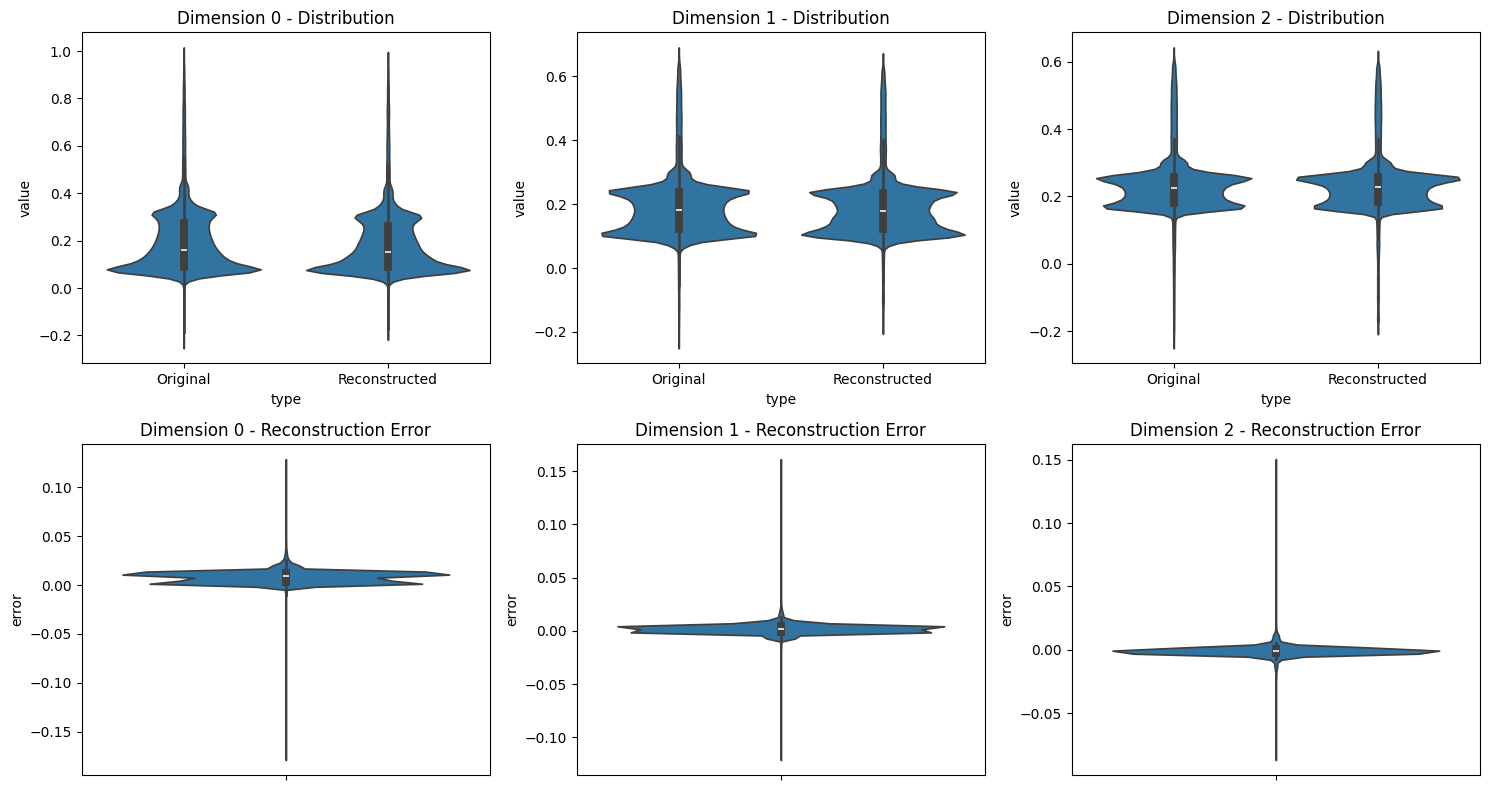

In [25]:
violin_plot(model, preprocessed_data["Xtest"], device, folder_path)